In [1]:
import cosmic
from cosmic.output import load_initC
import h5py as h5
import os
import pandas as pd
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from importlib import reload
from astropy.coordinates import SkyCoord
import seaborn as sns
from copy import copy

import corner
import legwork as lw
import gala.potential as gp
import cogsworth

import sys
sys.path.append("../helpers")

import detections
import const
import plotting
import uncertainties as unc

plt.rc('font', family='serif')
plt.rcParams['text.usetex'] = False
fs = 24

# update various fontsizes to match
params = {'figure.figsize': (12, 8),
          'legend.fontsize': 0.7*fs,
          'legend.title_fontsize': 0.8*fs,
          'axes.labelsize': fs,
          'xtick.labelsize': 0.9 * fs,
          'ytick.labelsize': 0.9 * fs,
          'axes.linewidth': 1.1,
          'xtick.major.size': 7,
          'xtick.minor.size': 4,
          'ytick.major.size': 7,
          'ytick.minor.size': 4}
plt.rcParams.update(params)

%config InlineBackend.figure_format = 'retina'

In [2]:
dfs = []
for variation in const.VARIATIONS:
    if variation == "fiducial":
        df_pess = pd.read_hdf(f"/mnt/ceph/users/twagg/lisa-dcos/{variation}/uncertainties_pessimistic.h5", key="distinguishers")
        df_pess["model"] = "fiducial"
        df_pess.index.name = "dco_type"
        dfs.append(df_pess)

    df = pd.read_hdf(f"/mnt/ceph/users/twagg/lisa-dcos/{variation}/uncertainties.h5", key="distinguishers")
    df.index.name = "dco_type"
    df["model"] = variation if variation != "fiducial" else "optimistic"
    dfs.append(df)

distinguishers = pd.concat(dfs, axis=0)
distinguishers = distinguishers.set_index(["model"], append=True).reorder_levels([1, 0] + list(range(2, distinguishers.index.nlevels + 1)))
distinguishers

too_low_freq  too_massive  measureable_eccentricity  \
model      dco_type                                                        
fiducial   BHBH             0.695        0.571                     0.093   
           BHNS             0.370        0.548                     0.240   
           BHWD             0.058        0.032                     0.000   
           NSNS             0.148        0.377                     0.404   
           NSWD             0.002        0.000                     0.000   
optimistic BHBH             0.729        0.504                     0.127   
           BHNS             0.374        0.504                     0.354   
           BHWD             0.033        0.149                     0.000   
           NSNS             0.142        0.136                     0.658   
           NSWD             0.003        0.000                     0.014   
alpha_low  BHBH             0.729        0.523                     0.109   
           BHNS             0.470        0.528                     0.215   
           BHWD             0.169        0.349                     0.000   
           NSNS             0.230        0.386                     0.504   
           NSWD             0.018        0.001                     0.000   
alpha_high BHBH             0.489        0.645                     0.131   
           BHNS             0.226        0.548                     0.215   
           BHWD             0.003        0.006                     0.000   
           NSNS             0.092        0.328                     0.252   
           NSWD             0.010        0.000                     0.001   
maltsev    BHBH             0.902        0.314                     0.026   
           BHNS             0.226        0.587                     0.227   
           BHWD             0.084        0.223                     0.000   
           NSNS             0.142        0.000                     0.491   
           NSWD             0.002        0.000                     0.000   
no_ecsn    BHBH             0.700        0.567                     0.093   
           BHNS             0.369        0.547                     0.242   
           BHWD             0.056        0.030                     0.000   
           NSNS             0.131        0.406                     0.396   
           NSWD             0.001        0.000                     0.003   
qcflag2    BHBH             0.694        0.569                     0.099   
           BHNS             0.361        0.545                     0.252   
           BHWD             0.056        0.007                     0.000   
           NSNS             0.149        0.377                     0.407   
           NSWD             0.003        0.000                     0.000   

                     too_far_from_plane  m_forb  m_forb_ecc  m_forb_ecc_z  
model      dco_type                                                        
fiducial   BHBH                   0.026   0.988       0.989         0.989  
           BHNS                   0.089   0.883       0.894         0.896  
           BHWD                   0.000   0.089       0.089         0.089  
           NSNS                   0.000   0.524       0.630         0.630  
           NSWD                   0.019   0.002       0.003         0.022  
optimistic BHBH                   0.015   0.989       0.990         0.990  
           BHNS                   0.055   0.845       0.889         0.891  
           BHWD                   0.000   0.182       0.182         0.182  
           NSNS                   0.000   0.277       0.723         0.723  
           NSWD                   0.014   0.003       0.017         0.031  
alpha_low  BHBH                   0.000   0.995       0.995         0.995  
           BHNS                   0.000   0.931       0.935         0.935  
           BHWD                   0.000   0.517       0.517         0.517  
           NSNS                   0.154   0.614       0.708         

In [3]:
model_labels={
    "fiducial": "Fiducial",
    "optimistic": "Optimistic CE",
    "alpha_low": r"$\alpha_{\rm CE} = 0.1$",
    "alpha_high": r"$\alpha_{\rm CE} = 10$",
    "maltsev": r"M25 remnants",
    "no_ecsn": "No ECSN",
    "qcflag2": r"C14 $q_{\rm crit}$"
}
model_labels_long={
    "fiducial": "Fiducial",
    "optimistic": "Optimistic CE",
    "alpha_low": r"Low efficiency CE, $\alpha_{\rm CE} = 0.1$",
    "alpha_high": r"High efficiency CE, $\alpha_{\rm CE} = 10$",
    "maltsev": r"Maltsev+2025 remnant masses",
    "no_ecsn": "No electron-capture supernovae",
    "qcflag2": r"Claeys+2014 critical mass ratios"
}

In [4]:
distinguishers

too_low_freq  too_massive  measureable_eccentricity  \
model      dco_type                                                        
fiducial   BHBH             0.695        0.571                     0.093   
           BHNS             0.370        0.548                     0.240   
           BHWD             0.058        0.032                     0.000   
           NSNS             0.148        0.377                     0.404   
           NSWD             0.002        0.000                     0.000   
optimistic BHBH             0.729        0.504                     0.127   
           BHNS             0.374        0.504                     0.354   
           BHWD             0.033        0.149                     0.000   
           NSNS             0.142        0.136                     0.658   
           NSWD             0.003        0.000                     0.014   
alpha_low  BHBH             0.729        0.523                     0.109   
           BHNS             0.470        0.528                     0.215   
           BHWD             0.169        0.349                     0.000   
           NSNS             0.230        0.386                     0.504   
           NSWD             0.018        0.001                     0.000   
alpha_high BHBH             0.489        0.645                     0.131   
           BHNS             0.226        0.548                     0.215   
           BHWD             0.003        0.006                     0.000   
           NSNS             0.092        0.328                     0.252   
           NSWD             0.010        0.000                     0.001   
maltsev    BHBH             0.902        0.314                     0.026   
           BHNS             0.226        0.587                     0.227   
           BHWD             0.084        0.223                     0.000   
           NSNS             0.142        0.000                     0.491   
           NSWD             0.002        0.000                     0.000   
no_ecsn    BHBH             0.700        0.567                     0.093   
           BHNS             0.369        0.547                     0.242   
           BHWD             0.056        0.030                     0.000   
           NSNS             0.131        0.406                     0.396   
           NSWD             0.001        0.000                     0.003   
qcflag2    BHBH             0.694        0.569                     0.099   
           BHNS             0.361        0.545                     0.252   
           BHWD             0.056        0.007                     0.000   
           NSNS             0.149        0.377                     0.407   
           NSWD             0.003        0.000                     0.000   

                     too_far_from_plane  m_forb  m_forb_ecc  m_forb_ecc_z  
model      dco_type                                                        
fiducial   BHBH                   0.026   0.988       0.989         0.989  
           BHNS                   0.089   0.883       0.894         0.896  
           BHWD                   0.000   0.089       0.089         0.089  
           NSNS                   0.000   0.524       0.630         0.630  
           NSWD                   0.019   0.002       0.003         0.022  
optimistic BHBH                   0.015   0.989       0.990         0.990  
           BHNS                   0.055   0.845       0.889         0.891  
           BHWD                   0.000   0.182       0.182         0.182  
           NSNS                   0.000   0.277       0.723         0.723  
           NSWD                   0.014   0.003       0.017         0.031  
alpha_low  BHBH                   0.000   0.995       0.995         0.995  
           BHNS                   0.000   0.931       0.935         0.935  
           BHWD                   0.000   0.517       0.517         0.517  
           NSNS                   0.154   0.614       0.708         

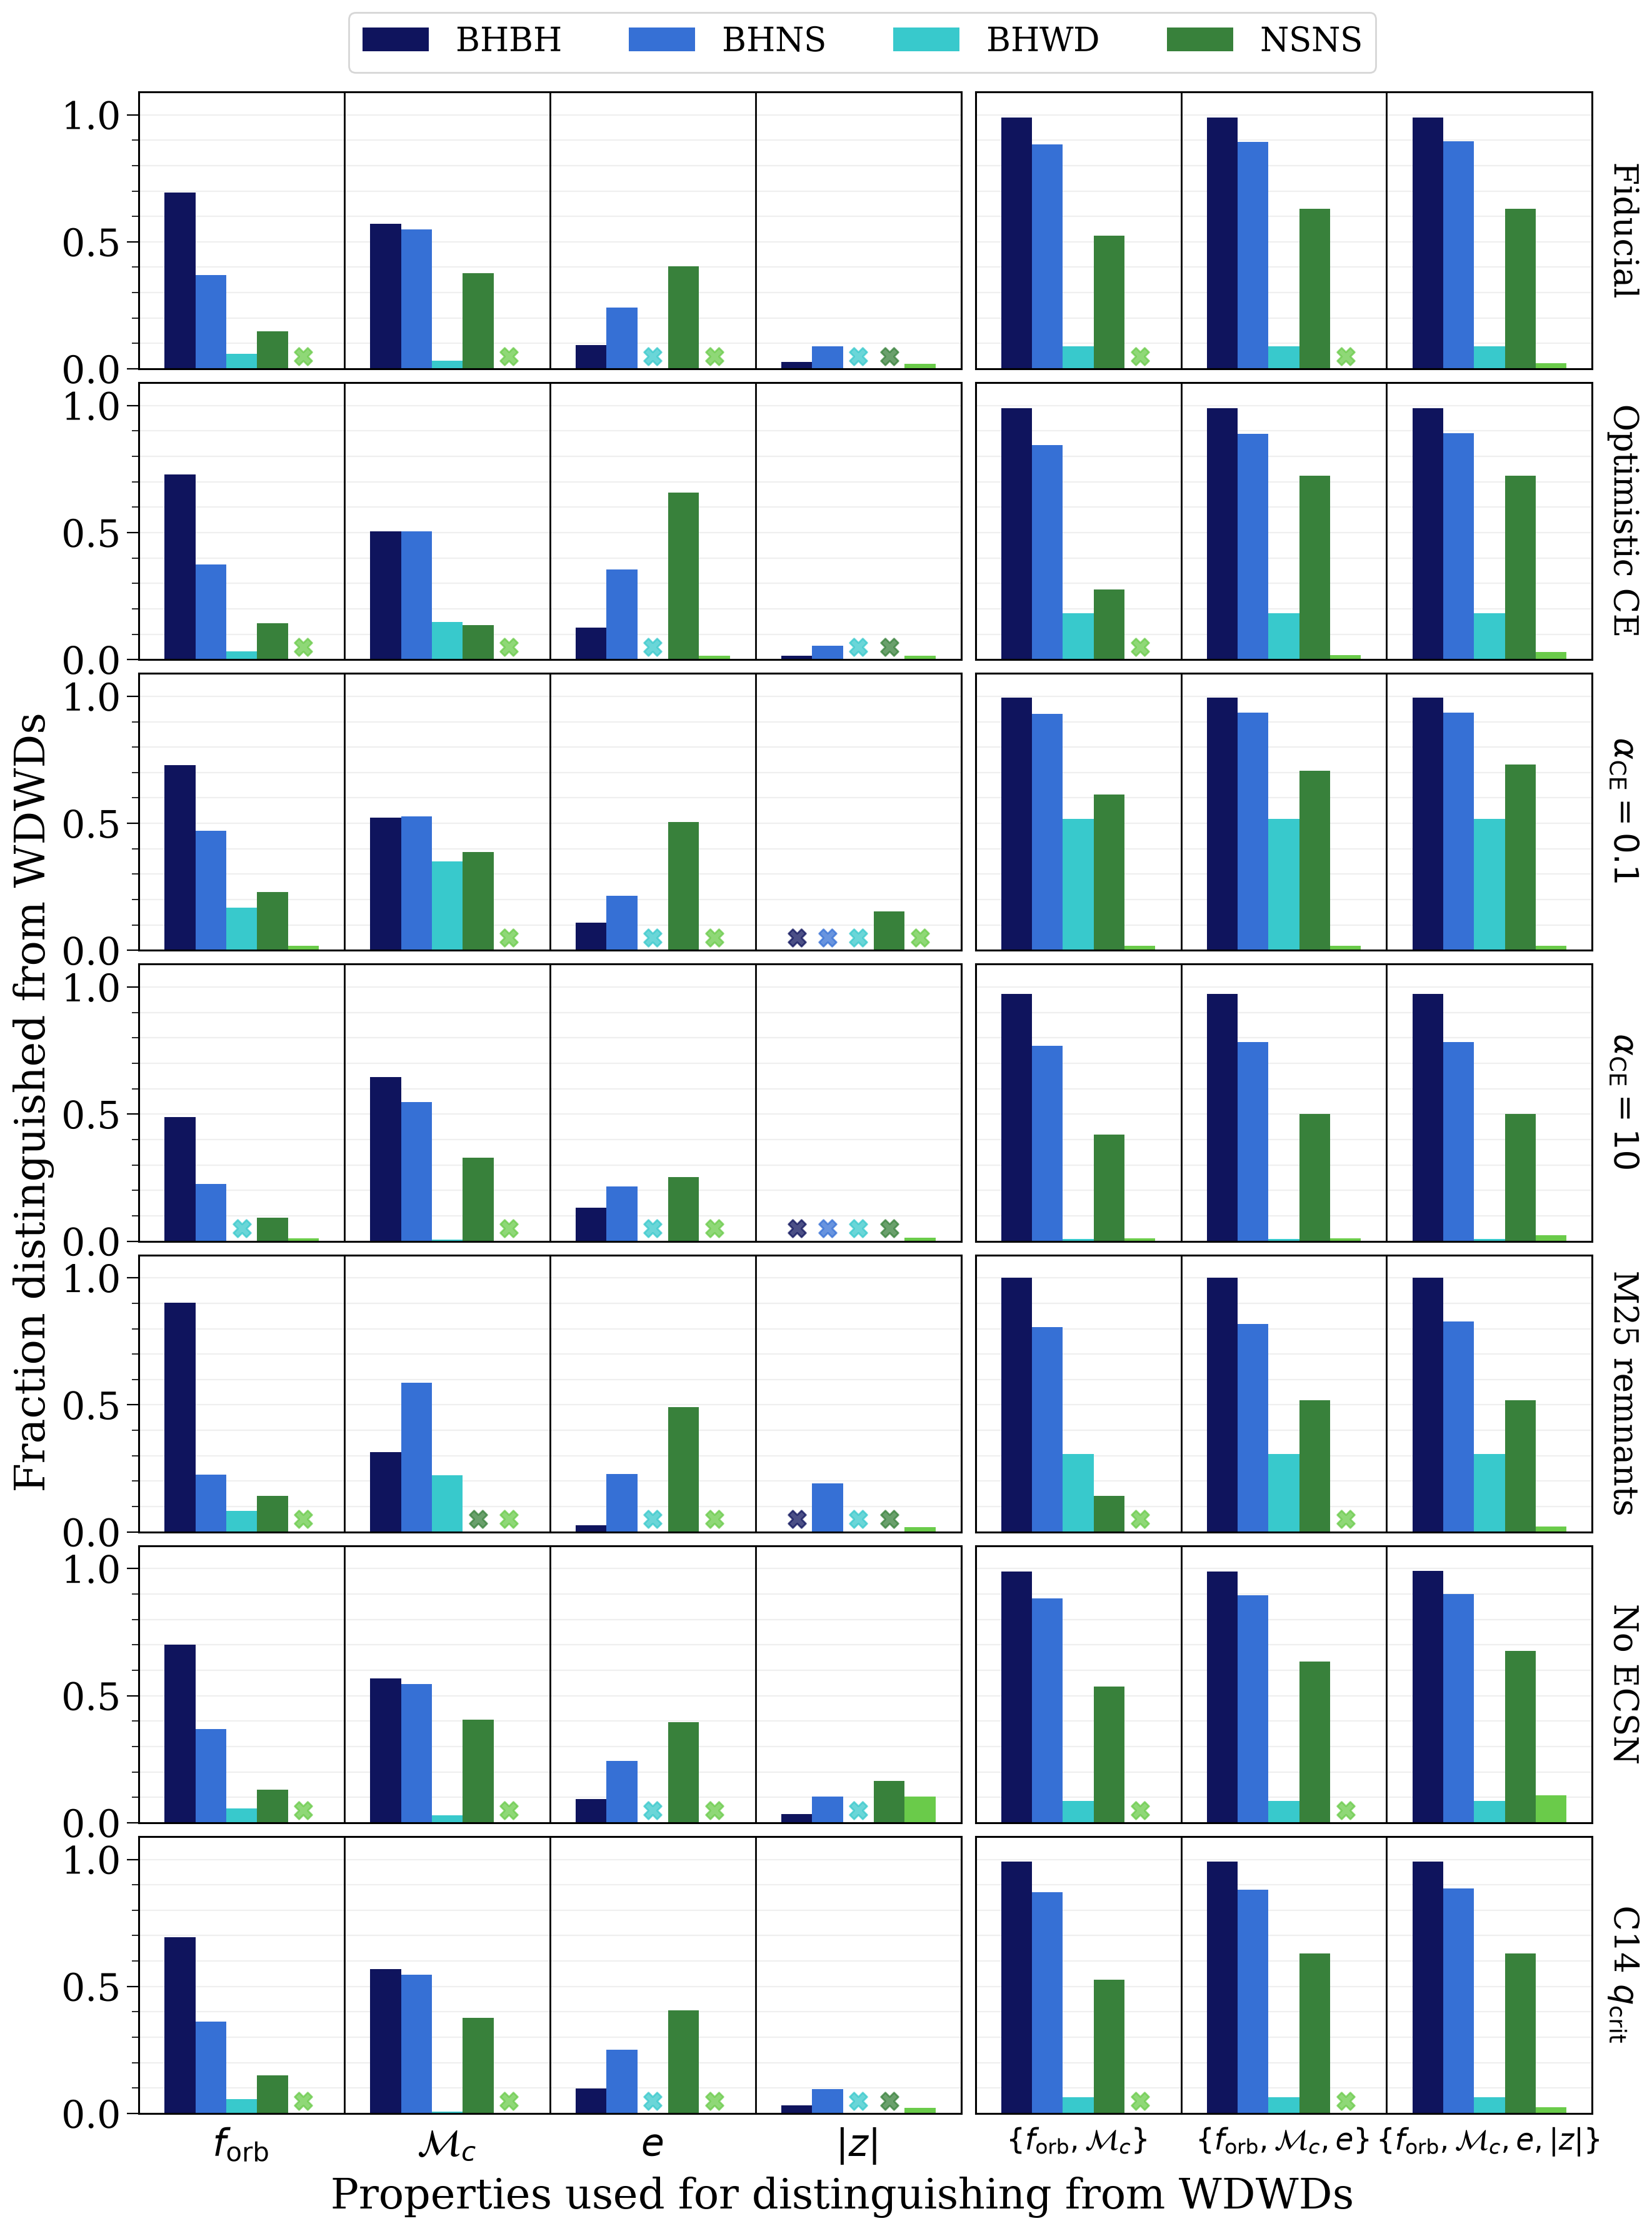

In [5]:
reload(plotting)
fig, axes = plotting.plot_wdwd_distinguishers(distinguishers, log_scale=False, save="../plots/distinguishers.pdf", model_labels=model_labels)

In [6]:
import matplotlib as mpl

In [7]:
np.array(list(mpl.colormaps["viridis"].colors[:7]))

array([[0.267004, 0.004874, 0.329415],
       [0.26851 , 0.009605, 0.335427],
       [0.269944, 0.014625, 0.341379],
       [0.271305, 0.019942, 0.347269],
       [0.272594, 0.025563, 0.353093],
       [0.273809, 0.031497, 0.358853],
       [0.274952, 0.037752, 0.364543]])

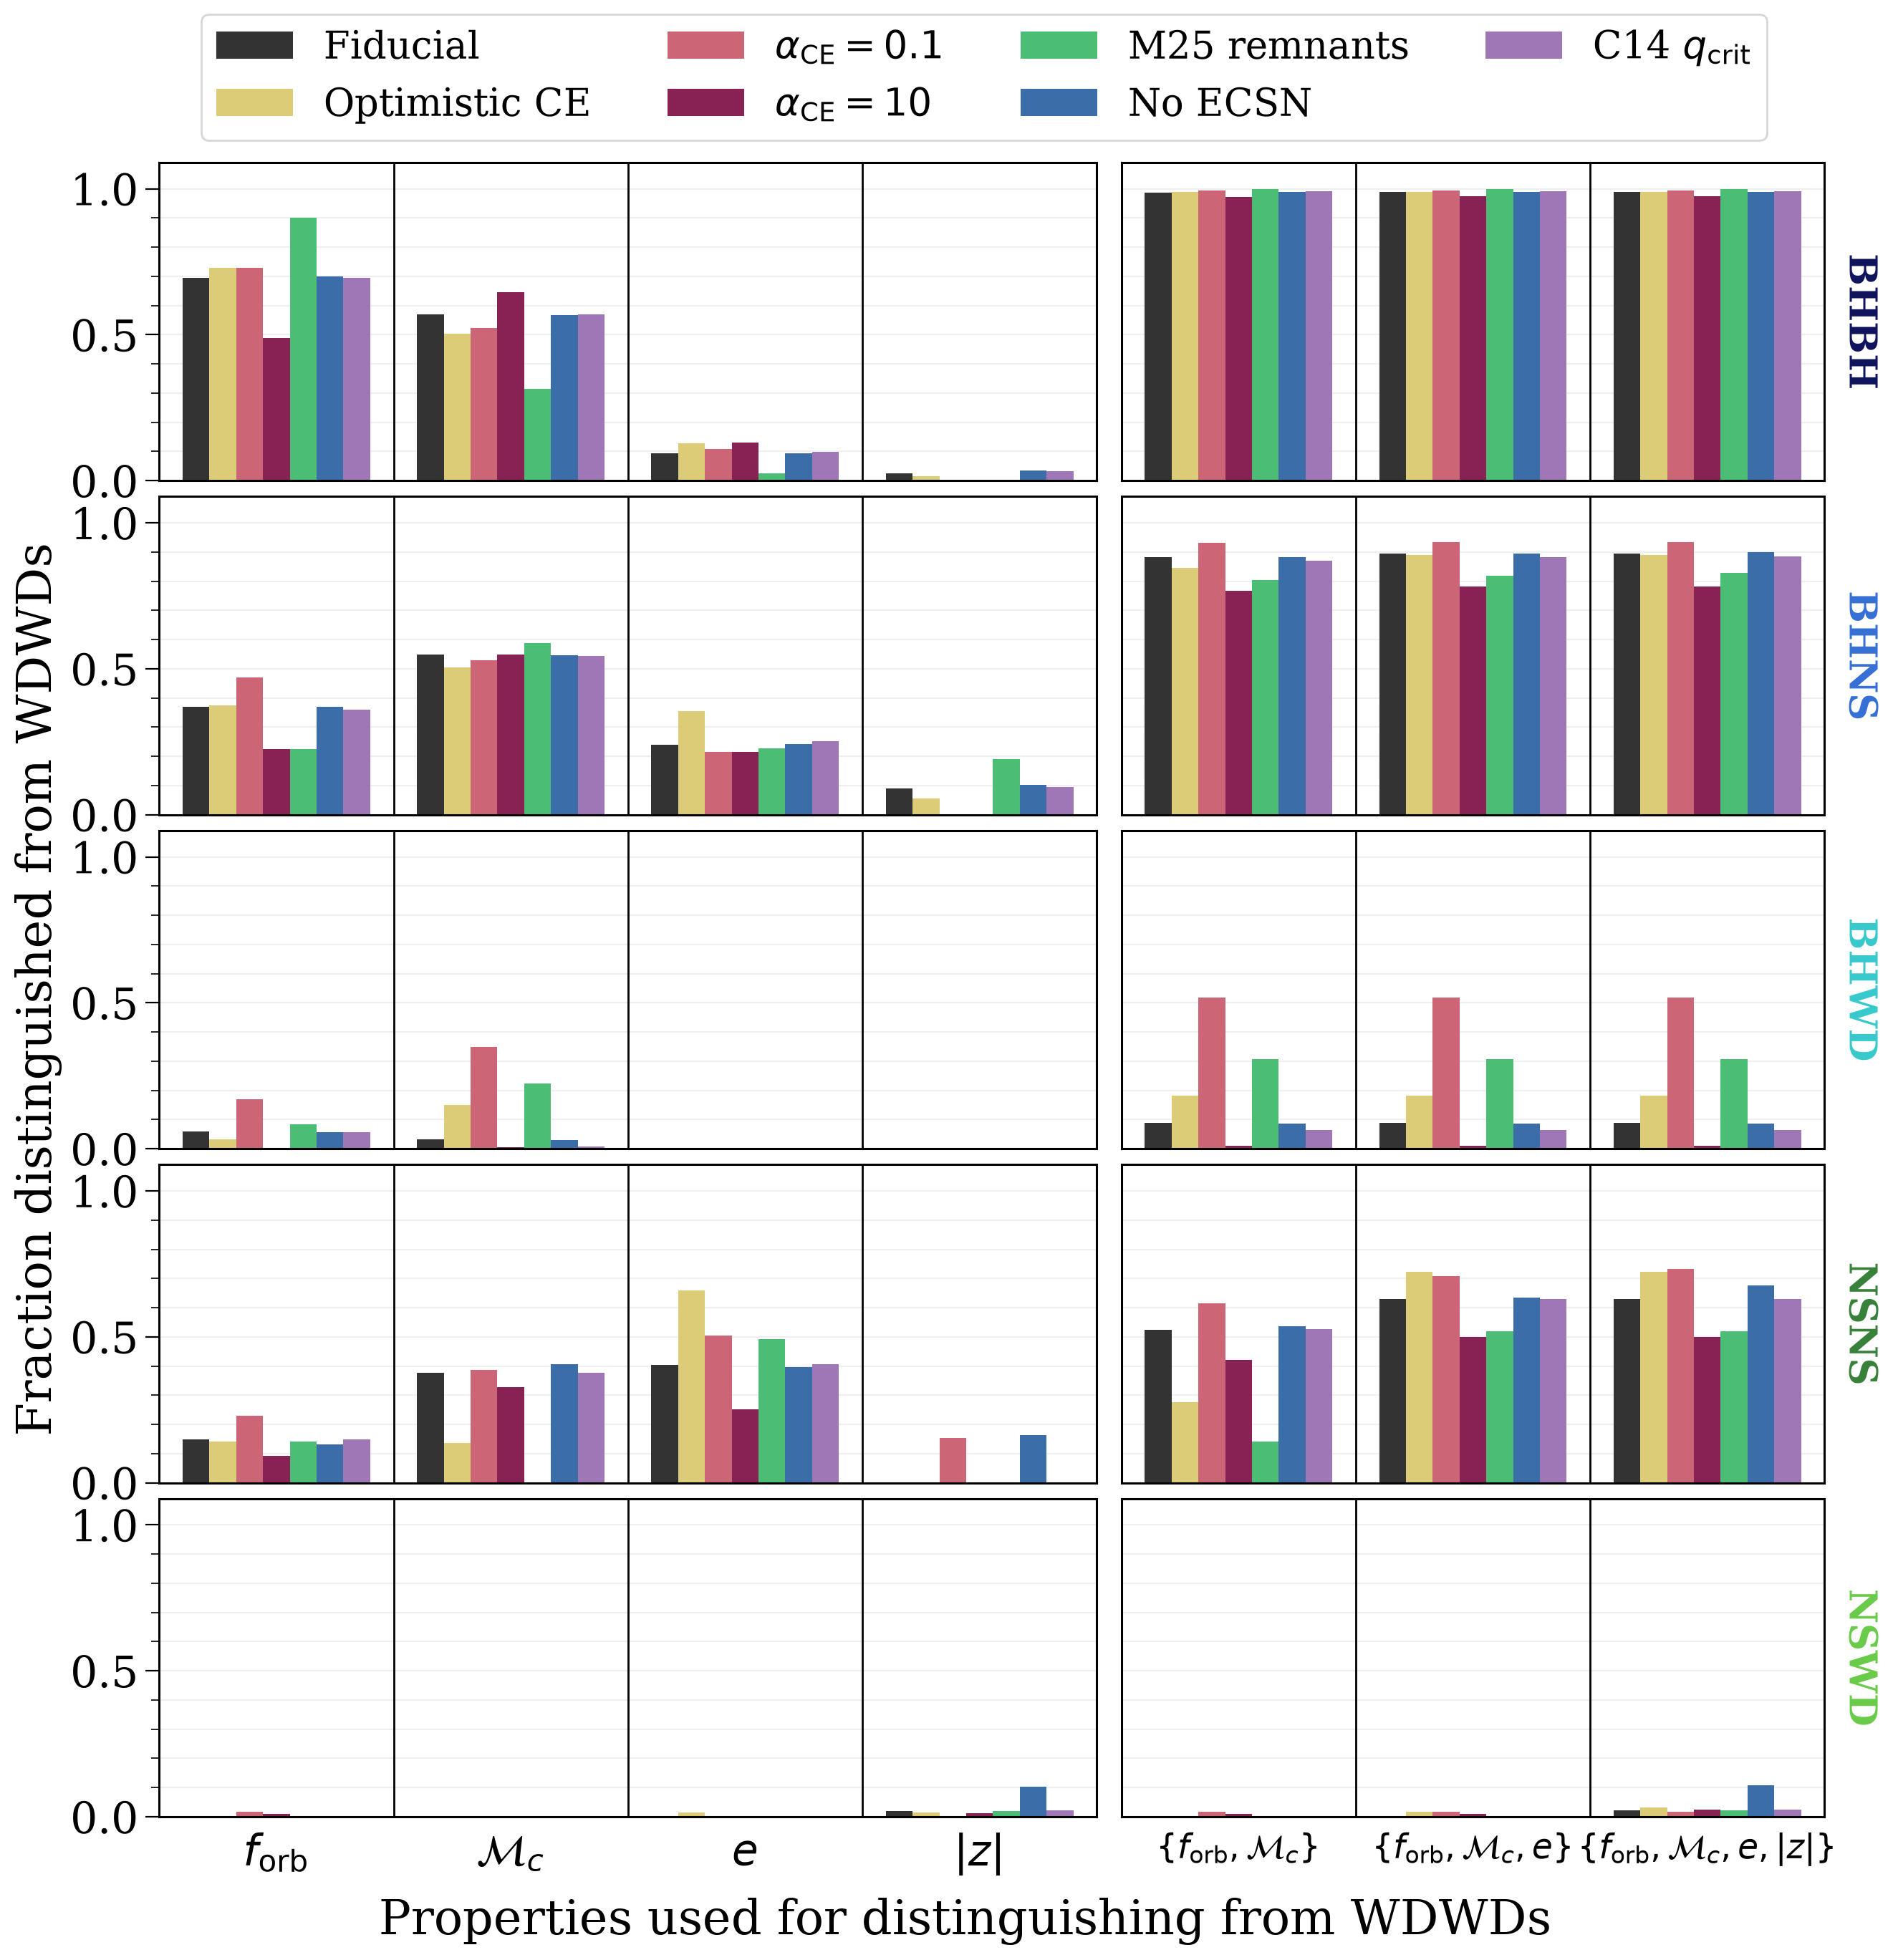

In [37]:
reload(plotting)
fig, axes = plotting.plot_wdwd_distinguishers_variations(
    distinguishers, log_scale=False, model_labels=model_labels,
    # cmap="okabe_ito"
    # cmap="rainbow", qualitative=False
    save="../plots/distinguishers.pdf",
    model_colours={
        "fiducial": "#333333",
        "optimistic": "#DDCC77",
        "alpha_low": "#CC6677",
        "alpha_high": "#882255",
        "maltsev": "#4CBD74",
        "no_ecsn": "#3B6DA9",
        "qcflag2": "#9F77B7"
    }
)

In [9]:
lw.source.Source(
    m_1=0.6 * u.Msun,
    m_2=0.6 * u.Msun,
    f_orb=2e-4 * u.Hz,
    ecc=0.0,
    dist=12 * u.pc,
    interpolate_g=False,
    sc_params={"t_obs": 8 * u.yr}
).get_snr()

array([190.19754098])

In [10]:
lw.source.Source(
    m_1=10 * u.Msun,
    m_2=10 * u.Msun,
    f_orb=2e-4 * u.Hz,
    ecc=0.0,
    dist=12 * u.pc,
    interpolate_g=False,
    sc_params={"t_obs": 8 * u.yr}
).get_snr()

array([20683.283295])

In [16]:
(lw.utils.chirp_mass(0.6, 0.6) / lw.utils.chirp_mass(10, 10))**(5/3)

0.00919571318872263